### Importing Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geojson
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from mpl_toolkits.basemap import Basemap
from matplotlib import cm
from descartes import PolygonPatch
from haversine import haversine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import MiniBatchKMeans

%matplotlib inline

### Loading Data Sets

#### Kaggle Data

---

In [13]:
df = pd.read_csv('D:\DataProject/New York Taxi/train.csv')
df['pickup_datetime']  = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


#### 2016 NYC Holidays

---

In [14]:
hf = pd.read_csv('D:\DataProject/New York Taxi/NYC_2016Holidays.csv', sep=';')

hf['Date'] = hf['Date'].apply(lambda x: x + ' 2016')
hf['Date']  = pd.to_datetime(hf['Date'])
hf

,Day,Date,Holiday
0,Friday,2016-01-01,New Years Day
1,Monday,2016-01-18,Martin Luther King Jr. Day
2,Friday,2016-02-12,Lincoln's Birthday
3,Monday,2016-02-15,Presidents' Day
4,Sunday,2016-05-08,Mother's Day
5,Monday,2016-05-30,Memorial Day
6,Sunday,2016-06-19,Father's Day
7,Monday,2016-07-04,Independence Day
8,Monday,2016-09-05,Labor Day
9,Monday,2016-10-10,Columbus Day


#### Weather

In [15]:
wf = pd.read_csv('D:\DataProject/New York Taxi/weather_data_nyc_centralpark_2016.csv')

wf['date'] = pd.to_datetime(wf['date'], format="%d-%m-%Y")

wf.head()


,date,maximum temerature,minimum temperature,average temperature,precipitation,snow fall,snow depth
0,2016-01-01,42,34,38.0,0.00,0.0,0
1,2016-01-02,40,32,36.0,0.00,0.0,0
2,2016-01-03,45,35,40.0,0.00,0.0,0
3,2016-01-04,36,14,25.0,0.00,0.0,0
4,2016-01-05,29,11,20.0,0.00,0.0,0


### Map Based Visualizations

In [16]:
min_lat = df['pickup_latitude'].min()
max_lat = df['pickup_latitude'].max()
min_lon = df['pickup_longitude'].min()
max_lon = df['pickup_longitude'].max()

print(min_lat, max_lat)
print(min_lon, max_lon)

34.35969543457031 51.88108444213867
-121.93334197998048 -61.33552932739258


Some points are far away from the boundaries of NYC. Let's limit the scope for visualization purposes, at least.

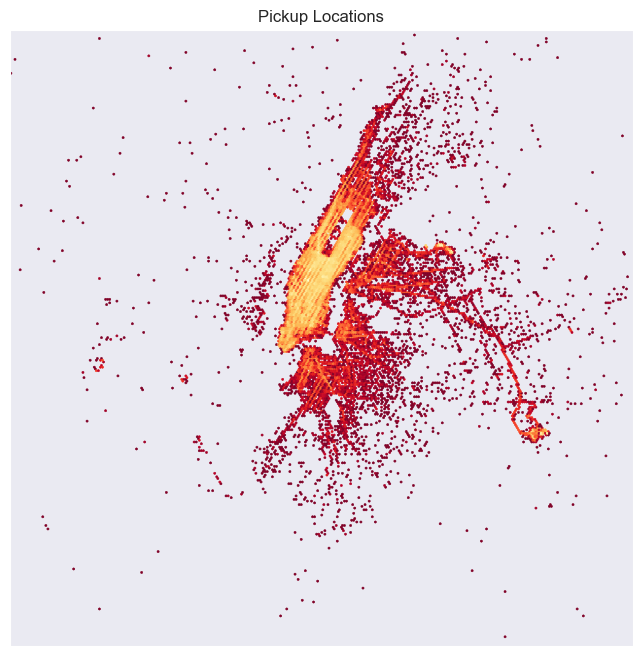

In [17]:
west, south, east, north = -74.26, 40.50, -73.70, 40.92
df = df[(df['pickup_longitude'] > west) & (df['pickup_longitude'] < east)]
df = df[(df['pickup_latitude'] > south) & (df['pickup_latitude'] < north)]

fig = plt.figure(figsize=(14,8))

m = Basemap(projection='merc', llcrnrlat=south, urcrnrlat=north,
            llcrnrlon=west, urcrnrlon=east, lat_ts=south, resolution='c')
x, y = m(df['pickup_longitude'].values, df['pickup_latitude'].values)
m.hexbin(x, y, gridsize=300, bins='log', cmap=cm.YlOrRd_r, lw=0.4)

plt.title('Pickup Locations')
plt.show()

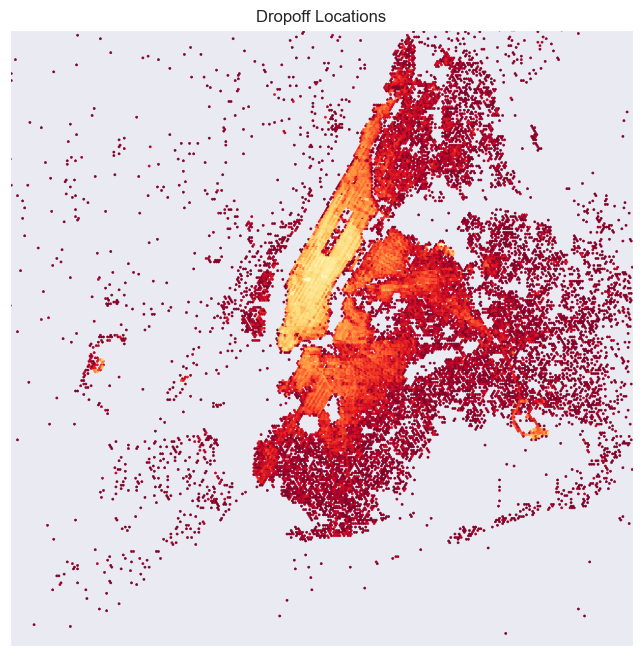

In [18]:
west, south, east, north = -74.26, 40.50, -73.70, 40.92
df = df[(df['dropoff_longitude'] > west) & (df['dropoff_longitude'] < east)]
df = df[(df['dropoff_latitude'] > south) & (df['dropoff_latitude'] < north)]

fig = plt.figure(figsize=(14,8))

m = Basemap(projection='merc', llcrnrlat=south, urcrnrlat=north,
            llcrnrlon=west, urcrnrlon=east, lat_ts=south, resolution='c')
x, y = m(df['dropoff_longitude'].values, df['dropoff_latitude'].values)
m.hexbin(x, y, gridsize=300, bins='log', cmap=cm.YlOrRd_r, lw=0.4)

plt.title('Dropoff Locations')
plt.show()

As can be seen, most of the tax trips pickups occurs in Manhattan and at JFK. Dropoffs, on the other hand, are better distributed in NYC. We can also note that some pickups/drop off points come from outside NYC while other seem to be locate overseas.  

### Feature Engineering

For feature engineering, I will create new date based attributes, as well as two new fields representing the distance covered and the average speed.

In [19]:
coords = np.vstack((df[['pickup_latitude',  'pickup_longitude']].values,
                    df[['dropoff_latitude', 'dropoff_longitude']].values,
                    df[['pickup_latitude',  'pickup_longitude']].values,
                    df[['dropoff_latitude', 'dropoff_longitude']].values))
kmeans = MiniBatchKMeans(n_clusters=100, batch_size=10000).fit(coords)

In [20]:
def derive_features(df):
    df = df.copy()
    # Pickup-based features
    df['pickup_date'] = df['pickup_datetime'].dt.date
    df['pickup_weekday'] = df['pickup_datetime'].dt.weekday
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_month'] = df['pickup_datetime'].dt.month
    df['pickup_day'] = df['pickup_datetime'].dt.day
    # Brand new features
    df['haversine_distance'] = df.apply(lambda x: haversine((x['pickup_latitude'],  x['pickup_longitude']),
                                                            (x['dropoff_latitude'], x['dropoff_longitude'])), axis=1)
    df['pickup_cluster']  = kmeans.predict(df[['pickup_latitude', 'pickup_longitude']])
    df['dropoff_cluster'] = kmeans.predict(df[['dropoff_latitude', 'dropoff_longitude']])
    return df

In [21]:
df = derive_features(df)

In [22]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_weekday,pickup_hour,pickup_month,pickup_day,haversine_distance,pickup_cluster,dropoff_cluster
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,0,17,3,14,1.498523,32,29
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,6,0,6,12,1.805510,76,37
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,1,11,1,19,6.385107,55,9
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,2,19,4,6,1.485500,84,71
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,5,13,3,26,1.188590,56,6


### Feature Visualizations

In [23]:
json_data = geojson.load(open('D:\DataProject/New York Taxi/community-districts-polygon.geojson'))
json_data.keys()
polygons = json_data['features']
FILL = '#6699cc'
CONT = '#1a169e'

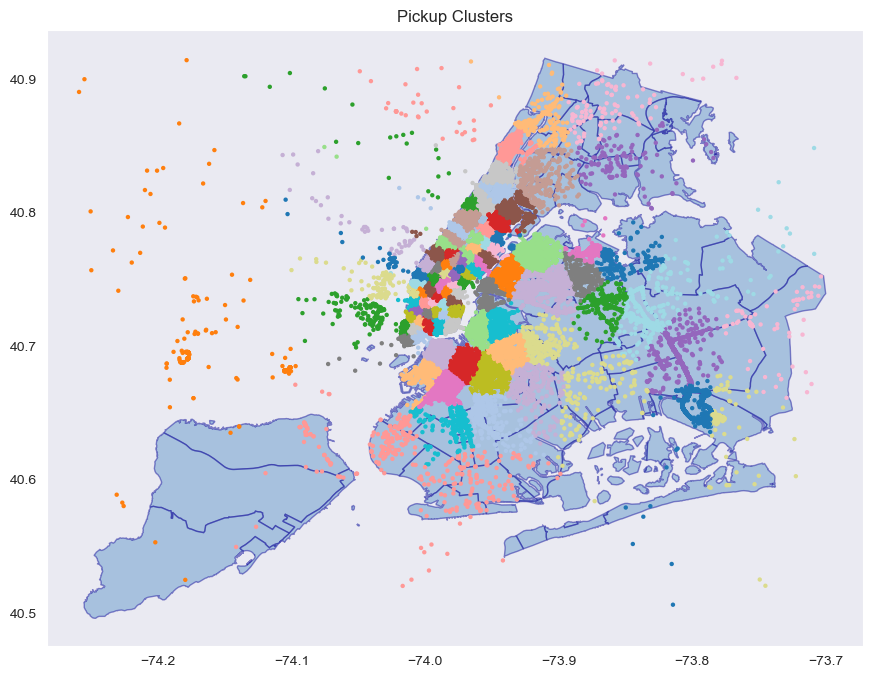

In [24]:
fig = plt.figure(figsize=(14,8))
ax = fig.gca() 

for i in range(len(polygons)):
    coordlist = polygons[i]['geometry']['coordinates']
    poly = {'type':'Polygon', 'coordinates':coordlist}
    ax.add_patch(PolygonPatch(poly, fc=FILL, ec=CONT, alpha=0.5, zorder=1))
    ax.axis('scaled')

ax.scatter(df['pickup_longitude'].values, df['pickup_latitude'], s=10, lw=0,
           c=df['pickup_cluster'].values, cmap='tab20', zorder=2)
plt.title('Pickup Clusters')
plt.grid(False)

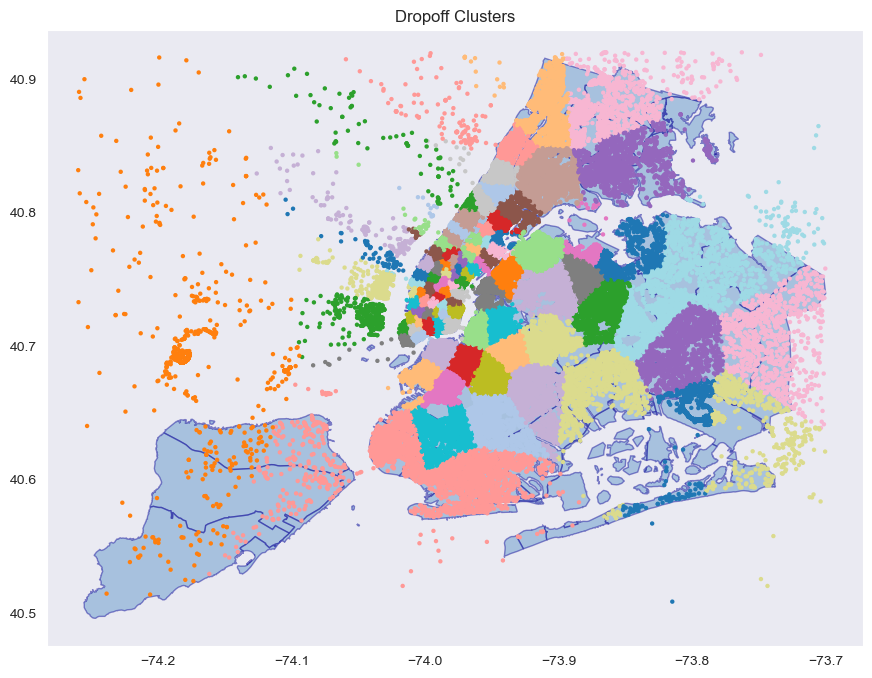

In [25]:
fig = plt.figure(figsize=(14,8))
ax = fig.gca() 

for i in range(len(polygons)):
    coordlist = polygons[i]['geometry']['coordinates']
    poly = {'type':'Polygon', 'coordinates':coordlist}
    ax.add_patch(PolygonPatch(poly, fc=FILL, ec=CONT, alpha=0.5, zorder=1))
    ax.axis('scaled')

ax.scatter(df['dropoff_longitude'].values, df['dropoff_latitude'], s=10, lw=0,
           c=df['dropoff_cluster'].values, cmap='tab20', zorder=2)
plt.title('Dropoff Clusters')
plt.grid(False)

<Axes: title={'center': 'Vendor ID'}, xlabel='vendor_id', ylabel='count'>

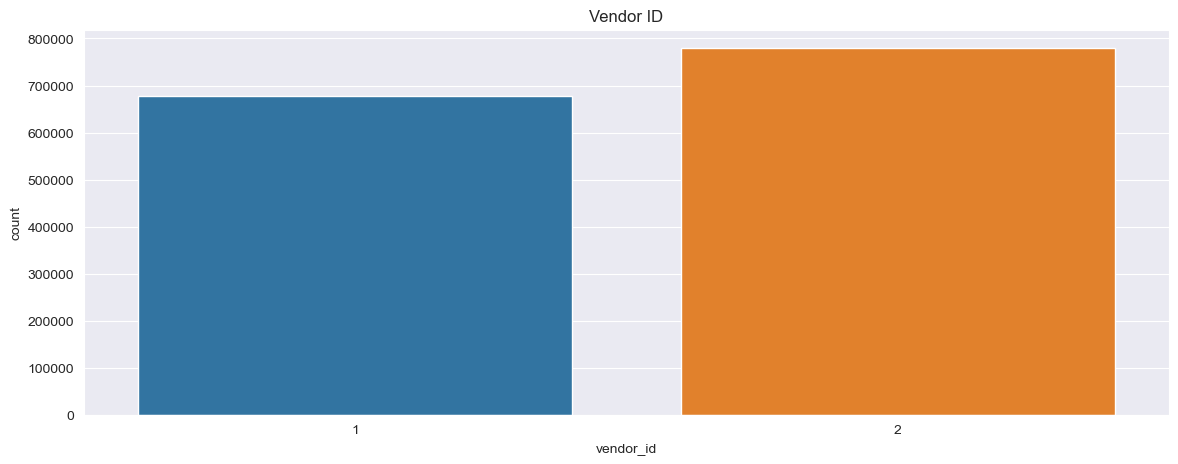

In [26]:
plt.figure(figsize=(14, 5))
plt.title('Vendor ID')
sns.countplot(x='vendor_id', data=df)

As can be seen, `vendor_id=2` performed more trips than `vendor_id=1`.

<Axes: title={'center': 'Trip Duration in Seconds'}, xlabel='trip_duration', ylabel='Density'>

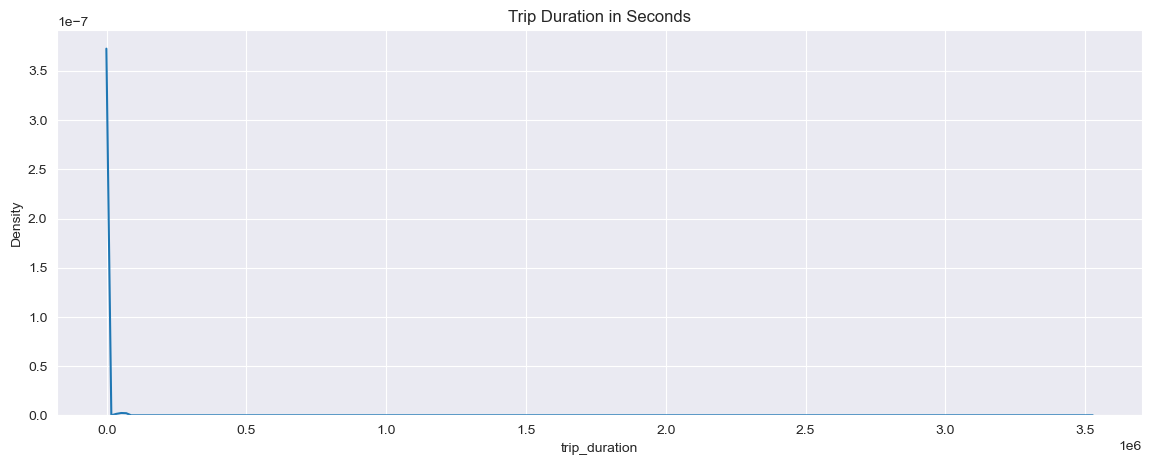

In [27]:
plt.figure(figsize=(14, 5))
plt.title('Trip Duration in Seconds')
sns.distplot(df['trip_duration'], hist=False)

Lot's of long trips, which will be discarded.

In [28]:
print('Mean trip duration (min): {0:.2f}'.format(df['trip_duration'].mean()/60))
print('Max trip duration (min): {0:.2f}'.format(df['trip_duration'].max()/60))
print('Median trip duration (min): {0:.2f}'.format(df['trip_duration'].median()/60))

Mean trip duration (min): 15.97
Max trip duration (min): 58771.37
Median trip duration (min): 11.03


<Axes: title={'center': 'Distance Traveled in km'}, xlabel='haversine_distance', ylabel='Density'>

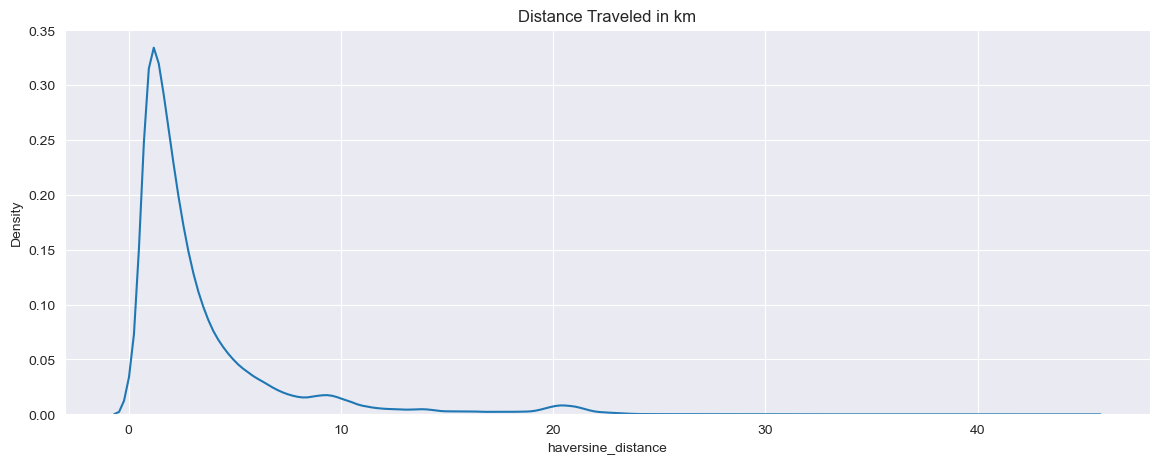

In [29]:
plt.figure(figsize=(14, 5))
plt.title('Distance Traveled in km')
sns.distplot(df['haversine_distance'], hist=False)

In [30]:
print('Mean trip distance (km): {0:.2f}'.format(df['haversine_distance'].mean()))
print('Max trip distance (km) {0:.2f}'.format(df['haversine_distance'].max()))
print('Median trip distance (km): {0:.2f}'.format(df['haversine_distance'].median()))

Mean trip distance (km): 3.42
Max trip distance (km) 45.11
Median trip distance (km): 2.09


<Axes: title={'center': 'Pickup per Weekday'}, xlabel='pickup_weekday', ylabel='count'>

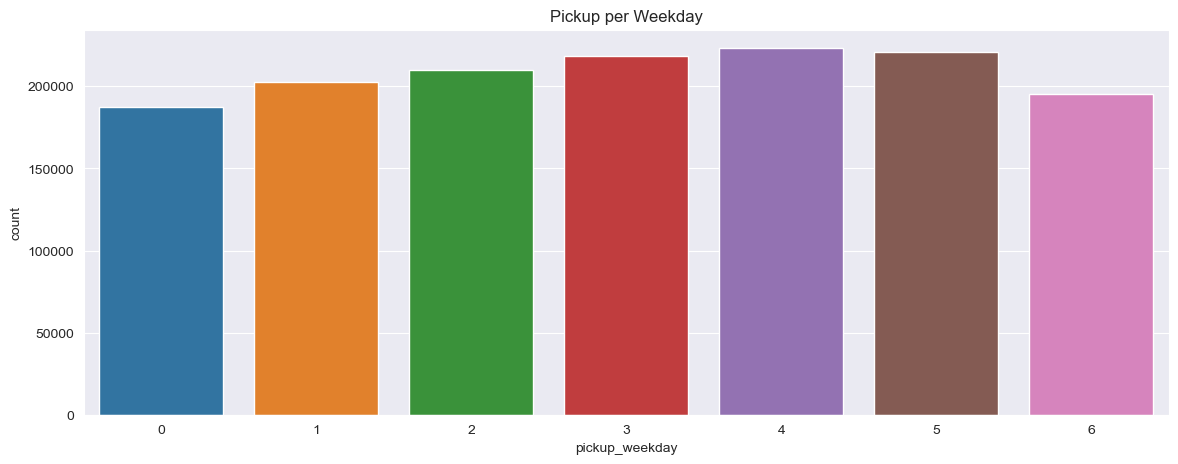

In [31]:
plt.figure(figsize=(14, 5))
plt.title('Pickup per Weekday')
sns.countplot(x='pickup_weekday', data=df)

<Axes: title={'center': 'Pickup per Hour'}, xlabel='pickup_hour', ylabel='count'>

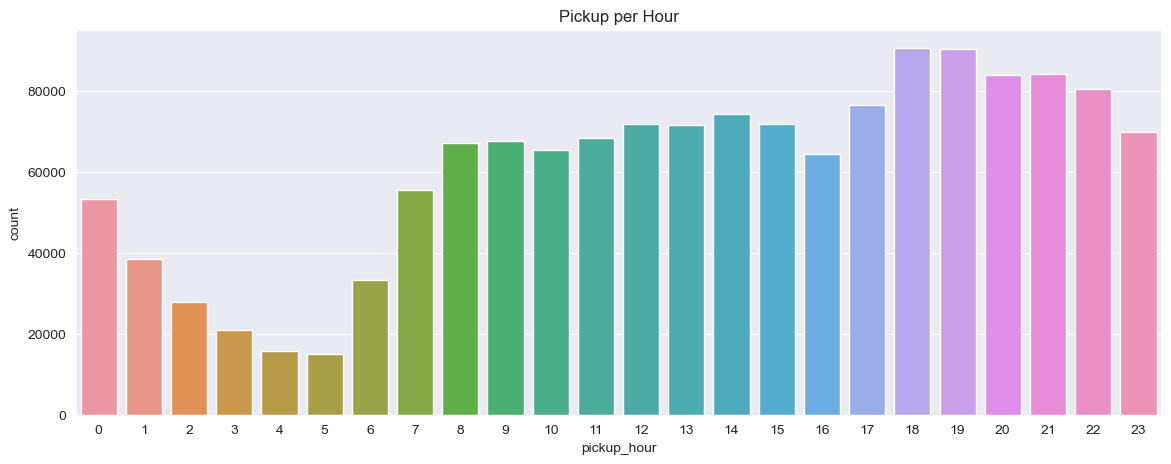

In [32]:
plt.figure(figsize=(14, 5))
plt.title('Pickup per Hour')
sns.countplot(x='pickup_hour', data=df)

More pickups during rush hours, decreasing after midnight...

<Axes: title={'center': 'Passenger'}, xlabel='passenger_count', ylabel='count'>

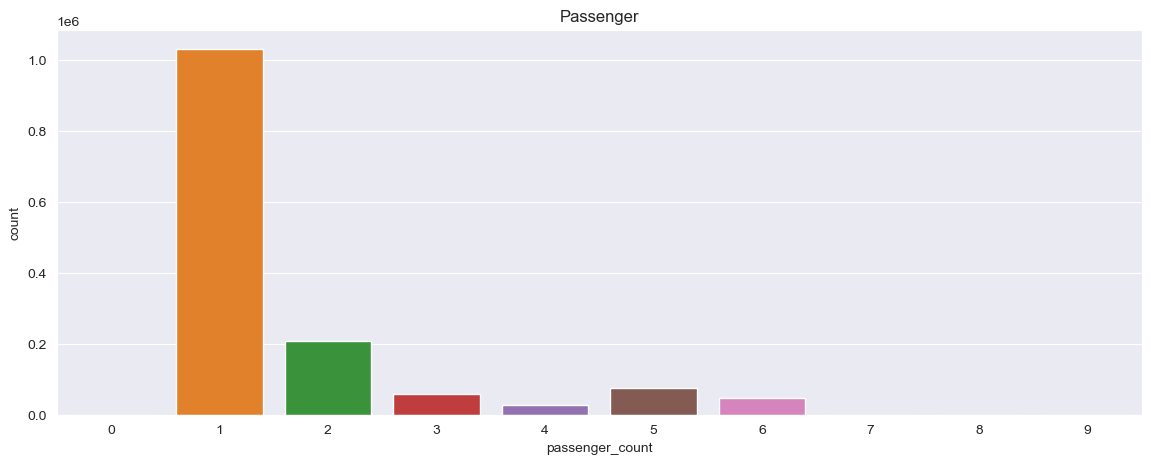

In [33]:
plt.figure(figsize=(14, 5))
plt.title('Passenger')
sns.countplot(x='passenger_count', data=df)

Most passengers travel alone.

<Axes: title={'center': 'Pickups per Month'}, xlabel='pickup_month', ylabel='count'>

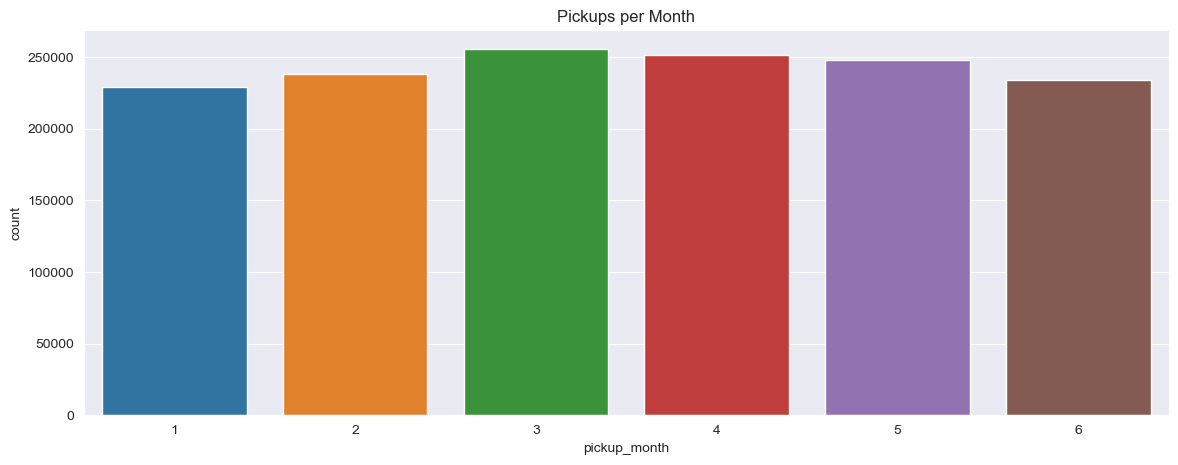

In [34]:
plt.figure(figsize=(14, 5))
plt.title('Pickups per Month')
sns.countplot(x='pickup_month', data=df)

### Trip Duration Relations

<Axes: title={'center': 'Duration per Weekday'}, xlabel='pickup_weekday', ylabel='trip_duration'>

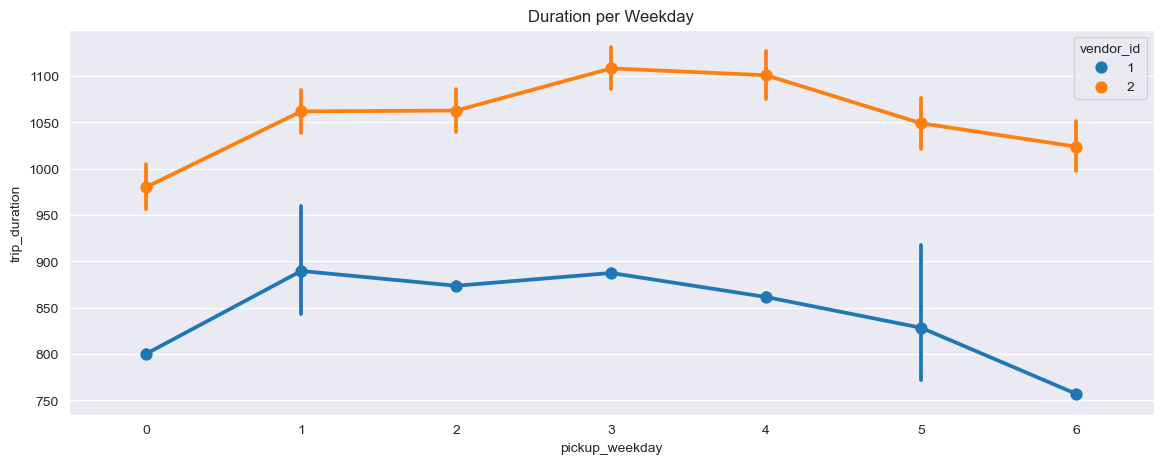

In [35]:
plt.figure(figsize=(14, 5))
plt.title('Duration per Weekday')
sns.pointplot(x='pickup_weekday', y='trip_duration', hue='vendor_id', data=df)

<Axes: title={'center': 'Duration per Hour'}, xlabel='pickup_hour', ylabel='trip_duration'>

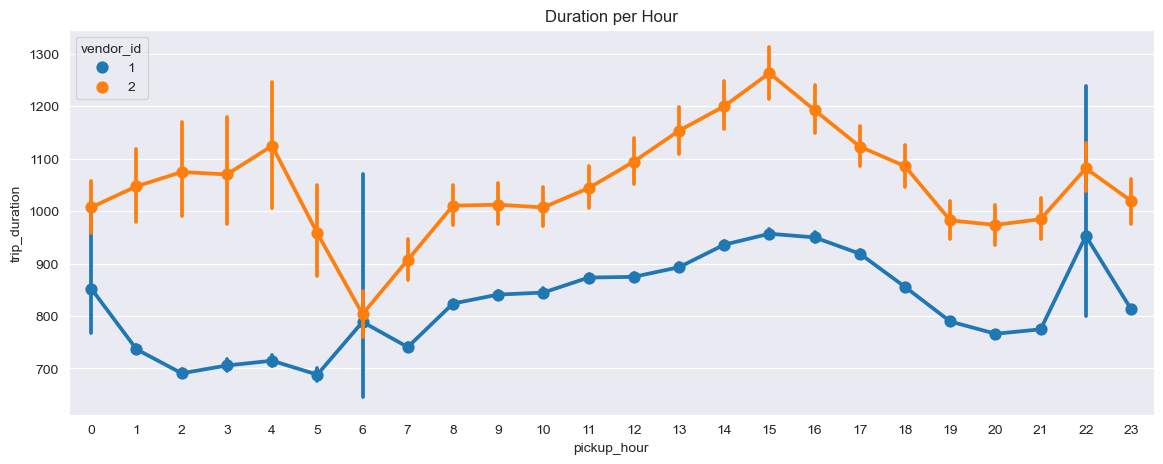

In [36]:
plt.figure(figsize=(14, 5))
plt.title('Duration per Hour')
sns.pointplot(x='pickup_hour', y='trip_duration', hue='vendor_id', data=df)

<Axes: title={'center': 'Duration per Month'}, xlabel='pickup_month', ylabel='trip_duration'>

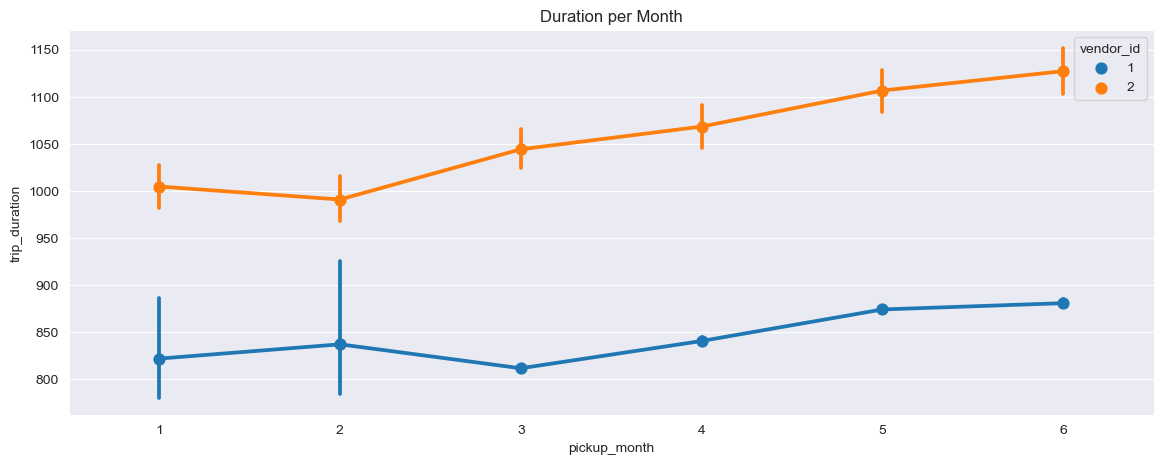

In [37]:
plt.figure(figsize=(14, 5))
plt.title('Duration per Month')
sns.pointplot(x='pickup_month', y='trip_duration', hue='vendor_id', data=df)

<Axes: title={'center': 'Duration per Passenger Count'}, xlabel='passenger_count', ylabel='trip_duration'>

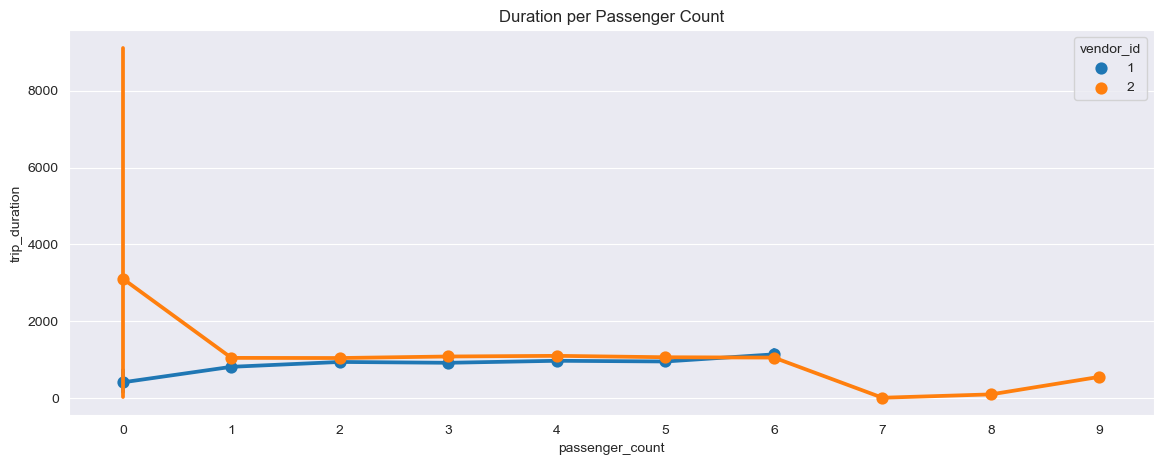

In [38]:
plt.figure(figsize=(14, 5))
plt.title('Duration per Passenger Count')
sns.pointplot(x='passenger_count', y='trip_duration', hue='vendor_id', data=df)

`vendor_id=2`, besides of taking more rides, also presents longer average trip duration in any weekdays. We can see that both vendors present a similar trip duration during 6am. However, in this case, `vendor_id=1` shows higher variability in the average trip duration. 

### Data Cleaning

Before modeling some outliers should be removed, as extreme long trips and records with null or extreme speeds.
I'll remove trips with the following features:

- Trip duration near 0s
- Trip duration longer than a day
- Near zero traveled distance

In [39]:
def clean_data(df):
    df = df.copy()
    df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 3600 * 24)] # Trip duration filtering
    df = df[(df['haversine_distance'] > 0.01)] # Distance filtering
    return df

In [40]:
df = clean_data(df)

#### Sanity Checking

---

<Axes: title={'center': 'Distance Traveled in km'}, xlabel='haversine_distance', ylabel='Density'>

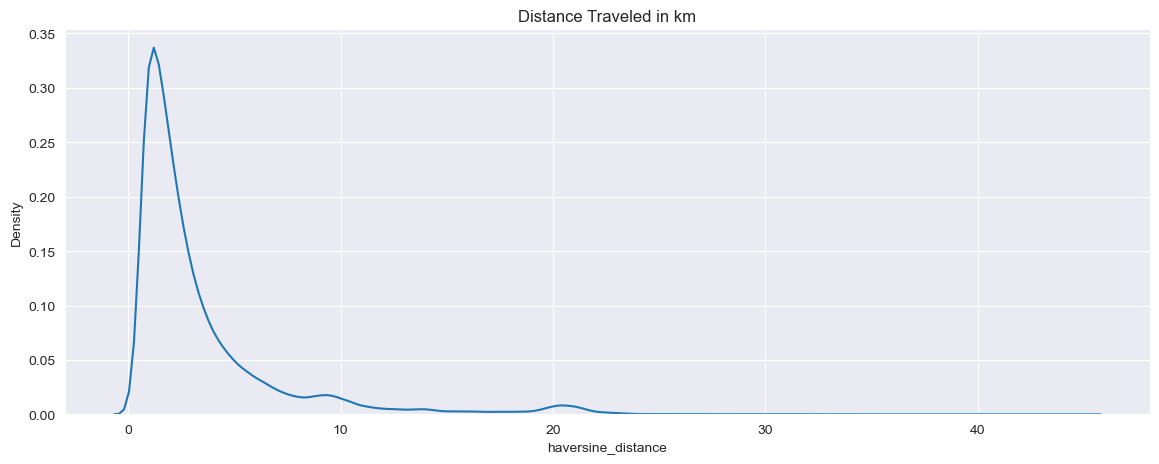

In [41]:
plt.figure(figsize=(14, 5))
plt.title('Distance Traveled in km')
sns.distplot(df['haversine_distance'], hist=False)

<Axes: title={'center': 'Trip Duration in Seconds'}, xlabel='trip_duration', ylabel='Density'>

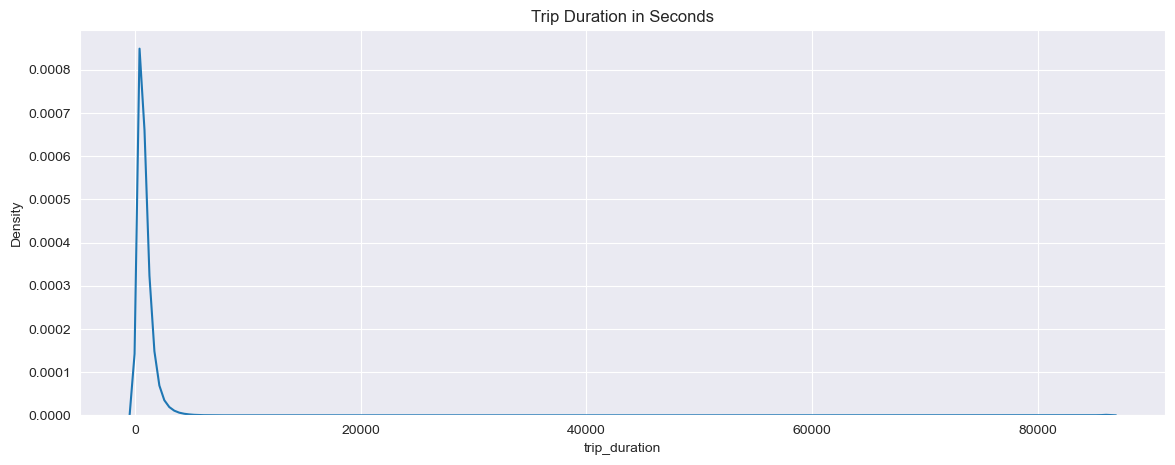

In [42]:
plt.figure(figsize=(14, 5))
plt.title('Trip Duration in Seconds')
sns.distplot(df['trip_duration'], hist=False)

In [43]:
print('Min trip distance (km): {0:.2f}'.format(df['haversine_distance'].min()))
print('Min trip duration (s): {0:.2f}'.format(df['trip_duration'].min()))

Min trip distance (km): 0.01
Min trip duration (s): 61.00


Okay, everything seems fine.

### External Data Sets

First, let's merge all data set with the weather data set. 

It's necessary to convert the traces (`T`) values into small numeric amounts and to convert columns that accept this value into numeric ones.

In [44]:
wf = wf.replace(to_replace='T', value=0.01)

wf['precipitation'] = pd.to_numeric(wf['precipitation'])
wf['snow fall'] = pd.to_numeric(wf['snow fall'])
wf['snow depth'] = pd.to_numeric(wf['snow depth'])

wf.tail()

,date,maximum temerature,minimum temperature,average temperature,precipitation,snow fall,snow depth
361,2016-12-27,60,40,50.0,0.00,0.00,0.0
362,2016-12-28,40,34,37.0,0.00,0.00,0.0
363,2016-12-29,46,33,39.5,0.39,0.00,0.0
364,2016-12-30,40,33,36.5,0.01,0.01,0.0
365,2016-12-31,44,31,37.5,0.00,0.00,0.0


In [45]:
df['pickup_date']   = pd.to_datetime(df['pickup_date'])
mf = df.merge(wf, left_on='pickup_date', right_on='date', how='inner')
mf.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,haversine_distance,pickup_cluster,dropoff_cluster,date,maximum temerature,minimum temperature,average temperature,precipitation,snow fall,snow depth
1443966,id0414189,2,2016-04-05 20:26:41,2016-04-05 20:49:50,1,-73.873192,40.774109,-74.010147,40.711491,N,...,13.476162,60,78,2016-04-05,43,26,34.5,0.0,0.0,0.0
1443967,id0392095,2,2016-04-05 12:32:31,2016-04-05 12:47:20,2,-73.966721,40.757389,-73.987961,40.736179,N,...,2.960365,90,30,2016-04-05,43,26,34.5,0.0,0.0,0.0
1443968,id2467939,2,2016-04-05 07:58:52,2016-04-05 08:11:02,2,-73.982269,40.772461,-73.965378,40.800949,N,...,3.472318,32,58,2016-04-05,43,26,34.5,0.0,0.0,0.0
1443969,id2221919,2,2016-04-05 23:03:38,2016-04-05 23:16:42,2,-73.986488,40.761898,-73.979988,40.732452,N,...,3.319685,12,54,2016-04-05,43,26,34.5,0.0,0.0,0.0
1443970,id1209952,1,2016-04-05 14:44:25,2016-04-05 14:47:43,1,-73.979538,40.781750,-73.972809,40.790585,N,...,1.134044,57,56,2016-04-05,43,26,34.5,0.0,0.0,0.0


In [46]:
mf.dtypes

id                             object
vendor_id                       int64
pickup_datetime        datetime64[ns]
dropoff_datetime       datetime64[ns]
passenger_count                 int64
pickup_longitude              float64
pickup_latitude               float64
dropoff_longitude             float64
dropoff_latitude              float64
store_and_fwd_flag             object
trip_duration                   int64
pickup_date            datetime64[ns]
pickup_weekday                  int32
pickup_hour                     int32
pickup_month                    int32
pickup_day                      int32
haversine_distance            float64
pickup_cluster                  int32
dropoff_cluster                 int32
date                   datetime64[ns]
maximum temerature              int64
minimum temperature             int64
average temperature           float64
precipitation                 float64
snow fall                     float64
snow depth                    float64
dtype: objec

All done.

Let's check how these variables correlates to each other.

### Correlation Between Features

Text(0.5, 1.0, 'Correlation between features')

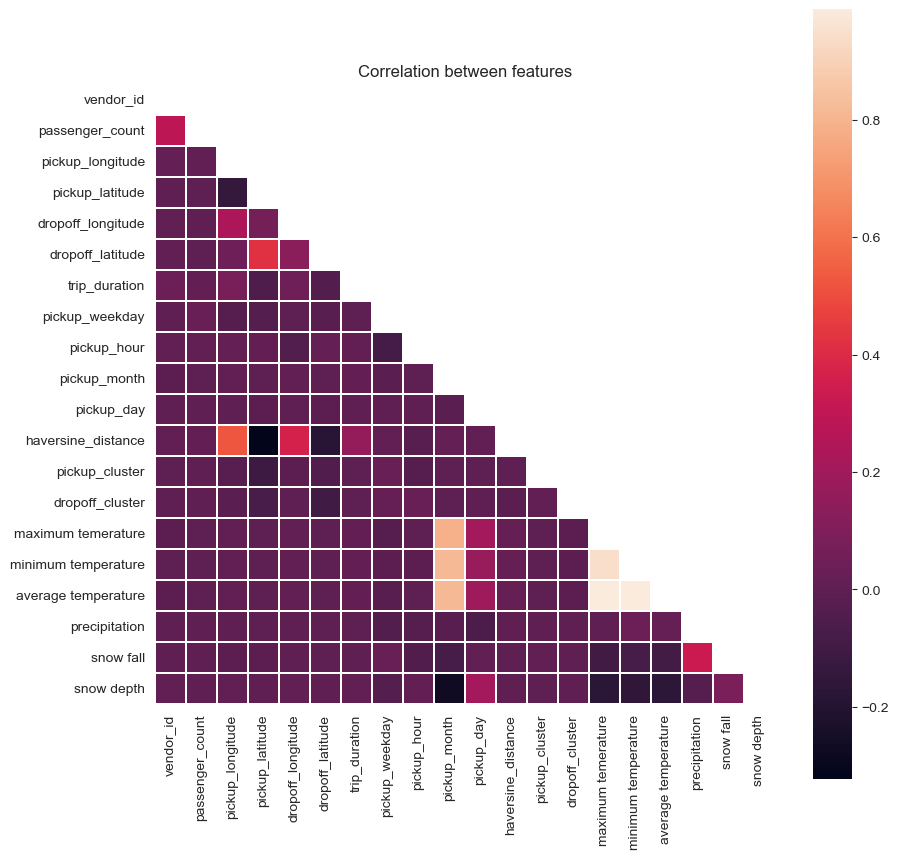

In [47]:
corr = mf.select_dtypes(include=[np.number]).corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10, 10))
with sns.axes_style('white'):
    sns.heatmap(corr, mask=mask, linewidths=0.01, square=True, linecolor='white')
plt.xticks(rotation=90)
plt.title('Correlation between features')

We can note a positive and strong correlation between (excluding correlation between features that present some sort of dependency on each other):

- (haversine_distance, pickup_longitude)
- (trip_duration, pickup_longitude)
- (_temperature, pickup_month)


Curiously there is a negative correlation between  (haversine_distance, pickup_latitude)

*Note that it doesn't make sense to analyse the correlation between the pickup and dropoff cluster variables with any other one. The same applies to vendor_id.* 

Just for fun, I'll also combine this data set with holidays flags. I believe that distance traveled and some other features may be dependant on holidays. However, as there are so few holidays in the year, I don't believe this information will be significant. Anyways, let's take a look 

In [48]:
mf = mf.merge(hf, left_on='pickup_date', right_on='Date', how='left')
mf.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,date,maximum temerature,minimum temperature,average temperature,precipitation,snow fall,snow depth,Day,Date,Holiday
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,2016-03-14,51,40,45.5,0.29,0.0,0.0,NaN,NaT,NaN
1,id2129090,1,2016-03-14 14:05:39,2016-03-14 14:28:05,1,-73.975090,40.758766,-73.953201,40.765068,N,...,2016-03-14,51,40,45.5,0.29,0.0,0.0,NaN,NaT,NaN
2,id0256505,1,2016-03-14 15:04:38,2016-03-14 15:16:13,1,-73.994484,40.745087,-73.998993,40.722710,N,...,2016-03-14,51,40,45.5,0.29,0.0,0.0,NaN,NaT,NaN
3,id3863815,2,2016-03-14 04:24:36,2016-03-14 04:37:11,3,-73.944359,40.714489,-73.910530,40.709492,N,...,2016-03-14,51,40,45.5,0.29,0.0,0.0,NaN,NaT,NaN
4,id3817493,2,2016-03-14 14:57:56,2016-03-14 15:15:26,1,-73.952881,40.766468,-73.978630,40.761921,N,...,2016-03-14,51,40,45.5,0.29,0.0,0.0,NaN,NaT,NaN


In [49]:
mf.loc[~mf['Holiday'].isnull(), 'Holiday'] = 1 
mf.loc[mf['Holiday'].isnull(), 'Holiday'] = 0

mf['Holiday'] = pd.to_numeric(mf['Holiday'])

mf['Holiday'].value_counts()

Holiday
0    1393404
1      50567
Name: count, dtype: int64

I'll drop any `datetime64` columns.

In [50]:
mf = mf.drop(['Day', 'Date', 'date', 'pickup_date'], axis=1)

### Feature Importances

Time for some modeling! I'll make use of sklearn in a first step to visualize feature importances.

In [51]:
mf.dtypes

id                             object
vendor_id                       int64
pickup_datetime        datetime64[ns]
dropoff_datetime       datetime64[ns]
passenger_count                 int64
pickup_longitude              float64
pickup_latitude               float64
dropoff_longitude             float64
dropoff_latitude              float64
store_and_fwd_flag             object
trip_duration                   int64
pickup_weekday                  int32
pickup_hour                     int32
pickup_month                    int32
pickup_day                      int32
haversine_distance            float64
pickup_cluster                  int32
dropoff_cluster                 int32
maximum temerature              int64
minimum temperature             int64
average temperature           float64
precipitation                 float64
snow fall                     float64
snow depth                    float64
Holiday                         int64
dtype: object

In [52]:
le = LabelEncoder()

for cat in ['store_and_fwd_flag', 'vendor_id']:
    mf[cat] = le.fit_transform(mf[cat])

In [53]:
X = mf.select_dtypes(include=[np.number])
X = X.drop(['trip_duration'], axis=1)
y = np.log1p(mf['trip_duration'])

Here I'm going to define a custom metric, used in this competition, to measure the models' performance.

In [54]:
def rmsle_eval(y, y0):
    y0 = y0.get_label()    
    assert len(y) == len(y0)
    return 'error', np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y0), 2)))

In [55]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

params = {}
params["objective"] = "reg:linear"
params["eta"] = 0.1
params["min_child_weight"] = 30
params["subsample"] = 0.8
params["colsample_bytree"] = 0.3
params["scale_pos_weight"] = 1.0
params["silent"] = 1
params["max_depth"] = 10
params["nthread"] = -1

plst = list(params.items())

model = xgb.train(plst, dtrain, 200, watchlist, early_stopping_rounds=50, maximize=False, 
                  verbose_eval=20, feval=rmsle_eval)

[00:12:55] WARNING: c:\users\dev-admin\croot2\xgboost-split_1675461376218\work\src\objective\regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[00:12:55] WARNING: C:\Users\dev-admin\croot2\xgboost-split_1675461376218\work\src\learner.cc:767: 
Parameters: { "silent" } are not used.

[0]	train-rmse:5.43932	train-error:1.27070	valid-rmse:5.44049	valid-error:1.27083
[20]	train-rmse:0.81818	train-error:0.10896	valid-rmse:0.82030	valid-error:0.10923
[40]	train-rmse:0.43203	train-error:0.05739	valid-rmse:0.43692	valid-error:0.05799
[60]	train-rmse:0.39587	train-error:0.05273	valid-rmse:0.40347	valid-error:0.05371
[80]	train-rmse:0.38453	train-error:0.05113	valid-rmse:0.39428	valid-error:0.05242
[100]	train-rmse:0.37595	train-error:0.04991	valid-rmse:0.38737	valid-error:0.05143
[120]	train-rmse:0.37074	train-error:0.04919	valid-rmse:0.38363	valid-error:0.05091
[140]	train-rmse:0.36523	train-error:0.04840	valid-rmse:0.37989	valid-error:0.05038
[160]	train-rmse:0.

In [56]:
def plot_importances(clf):
    importances = clf.get_fscore()
    importances = sorted(importances.items(), key=lambda x: x[1])
    x = list(zip(*importances))[0]
    y = list(zip(*importances))[1]
    x_pos = np.arange(len(x)) 
    plt.figure(figsize=(10,5))
    plt.title('Feature importances')
    plt.barh(range(len(y)), y, align='center')
    plt.yticks(range(len(y)), x)
    plt.ylim([-1, len(importances)])
    plt.xlabel('F score')
    plt.show()

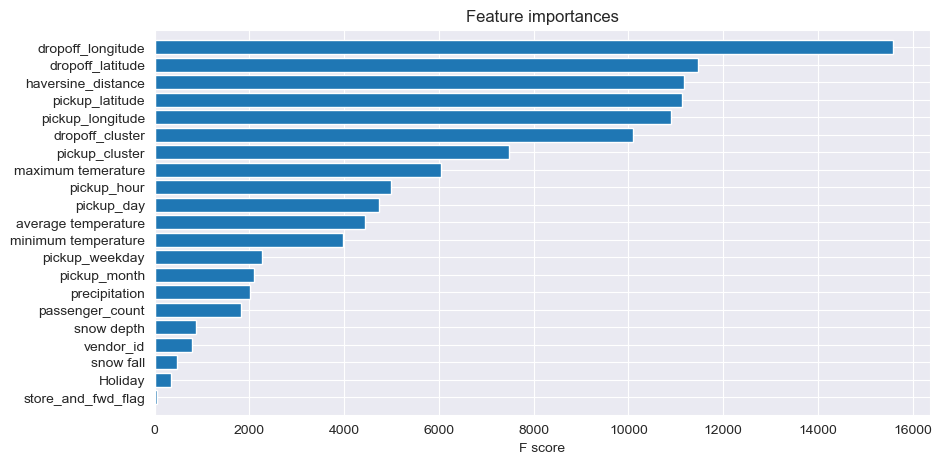

In [57]:
plot_importances(model)

### MODEL EVALUATION

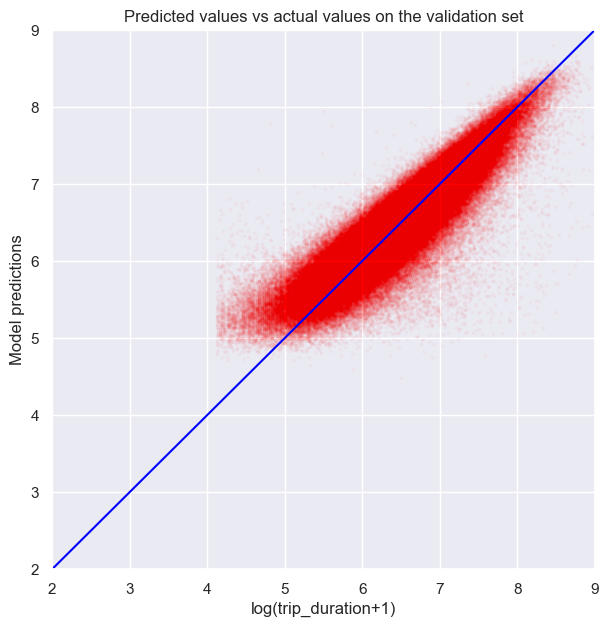

In [70]:
# model evaluation predicted vs actual values on validation set
pred_val = model.predict(xgb.DMatrix(X_valid))

sns.set(font_scale=1)
plt.figure(figsize=(7, 7))
plt.scatter(y_valid, pred_val, s=3, color='red', alpha=0.025)
plt.plot([1,9],[1,9], color='blue')
plt.title('Predicted values vs actual values on the validation set')
plt.xlabel('log(trip_duration+1)')
plt.ylabel('Model predictions')
axes = plt.gca()
axes.set_xlim([2, 9])
axes.set_ylim([2, 9])
plt.show()
plt.show()

### Submission

It will be necessary apply all the transformations and feature engineering to the test data set.

In [58]:
tf = pd.read_csv('D:\DataProject/New York Taxi/test.csv')
ids = tf['id']
tf['pickup_datetime']  = pd.to_datetime(tf['pickup_datetime'])

In [59]:
tf = derive_features(tf)

In [60]:
tf['pickup_date']   = pd.to_datetime(tf['pickup_date'])
tf = tf.merge(wf, left_on='pickup_date', right_on='date', how='inner')

In [61]:
tf = tf.merge(hf, left_on='pickup_date', right_on='Date', how='left')
tf.loc[~tf['Holiday'].isnull(), 'Holiday'] = 1 
tf.loc[tf['Holiday'].isnull(), 'Holiday'] = 0

tf['Holiday'] = pd.to_numeric(tf['Holiday'])

tf['Holiday'].value_counts()

Holiday
0    603252
1     21882
Name: count, dtype: int64

In [62]:
le = LabelEncoder()

for cat in ['store_and_fwd_flag', 'vendor_id']:
    tf[cat] = le.fit_transform(tf[cat])

In [63]:
tf = tf.drop(['Day', 'Date', 'date', 'pickup_date'], axis=1)

In [64]:
tf = tf.select_dtypes(include=[np.number])

In [65]:
dtest = xgb.DMatrix(tf)
ytest = model.predict(dtest)

In [67]:
submission = pd.DataFrame({'id': ids, 'trip_duration': np.expm1(ytest)})
submission.to_csv('nyc-20212390077-周小梵-output.csv', index=False)